## Grupowanie hierarchiczne


In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.datasets import load_iris
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

iris = load_iris()
X = iris.data
feature_names = iris.feature_names

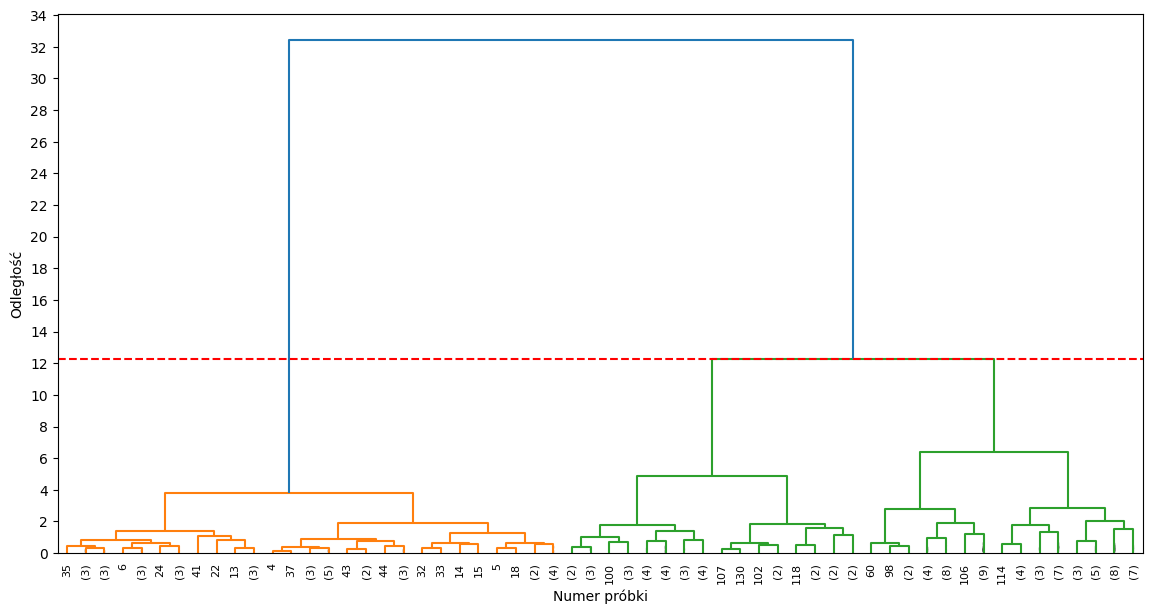

In [2]:
linked = linkage(X, 'ward')

plt.figure(figsize=(14, 7))

dendrogram(linked, truncate_mode='level', p=5,  leaf_rotation=90, leaf_font_size=8., show_contracted=True)

roznice = np.diff(linked[:, 2])
maks_skok = np.argmax(roznice)
optymalny_prog = linked[maks_skok, 2]

plt.xlabel('Numer próbki')
plt.yticks(range(0, 35, 2))
plt.ylabel('Odległość')

plt.axhline(y = optymalny_prog, color='r', linestyle='--')

plt.show()

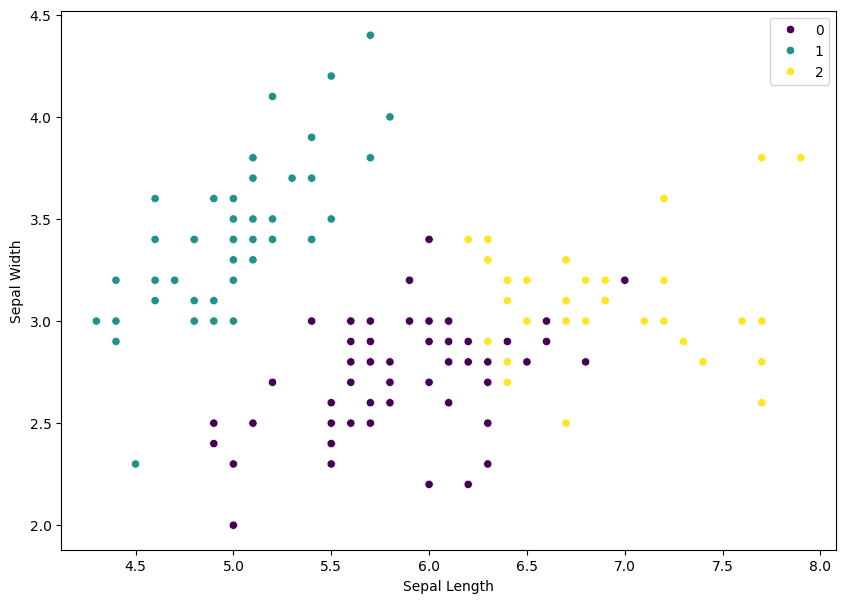

In [3]:
clustering = AgglomerativeClustering(n_clusters=None, distance_threshold = optymalny_prog)
clustering.fit(X);

plt.figure(figsize=(10, 7))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=clustering.labels_, palette='viridis')

plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.show()